In [5]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sasviya.ml.linear_model import LinearRegression
from sasviya.ml.svm import SVR
import matplotlib.pyplot as plt

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")



In [6]:
# We also set basic display and visualisation options to improve the readability of outputs and plots throughout the notebook 
%matplotlib inline

# Display all rows and columns in output if needed
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
data = pd.read_csv("sas-viya-workbench-examples/data/bike_sharing_demand.csv")
# Split the data into Train, Validation, and Test sets (40% Train, 30% Validation, 30% Test)
train_data, temp_test_data = train_test_split(data, test_size=0.6, random_state=42)
val_data, test_data = train_test_split(temp_test_data, test_size=0.5, random_state=42)

# Create X and y variables for modeling
X_train, y_train = train_data.drop(columns=['count']), train_data['count']
X_val, y_val = val_data.drop(columns=['count']), val_data['count']
X_test, y_test = test_data.drop(columns=['count']), test_data['count']

# Print first 5 rows of train dataset
print("Top 5 rows of bikesharing train dataset:")
print(train_data.head(5))

Top 5 rows of bikesharing train dataset:
            date  season  year  month  hour  holiday  weekday  workingday  \
14836  9/15/2012       3     1      9     9        0        6           0   
4813   7/24/2011       3     0      7    11        0        0           0   
9265   1/26/2012       1     1      1    23        0        4           1   
5969   9/11/2011       3     0      9     6        0        0           0   
2939    5/7/2011       2     0      5     9        0        6           0   

       weather  temp   atemp  humidity  windspeed  casual  registered  count  
14836        1  0.60  0.6212      0.43     0.4179      79         263    342  
4813         1  0.84  0.8030      0.53     0.2537      74         169    243  
9265         2  0.40  0.4091      0.82     0.0000       5          86     91  
5969         1  0.58  0.5455      0.88     0.1045       4          16     20  
2939         1  0.54  0.5152      0.49     0.2836      54         164    218  


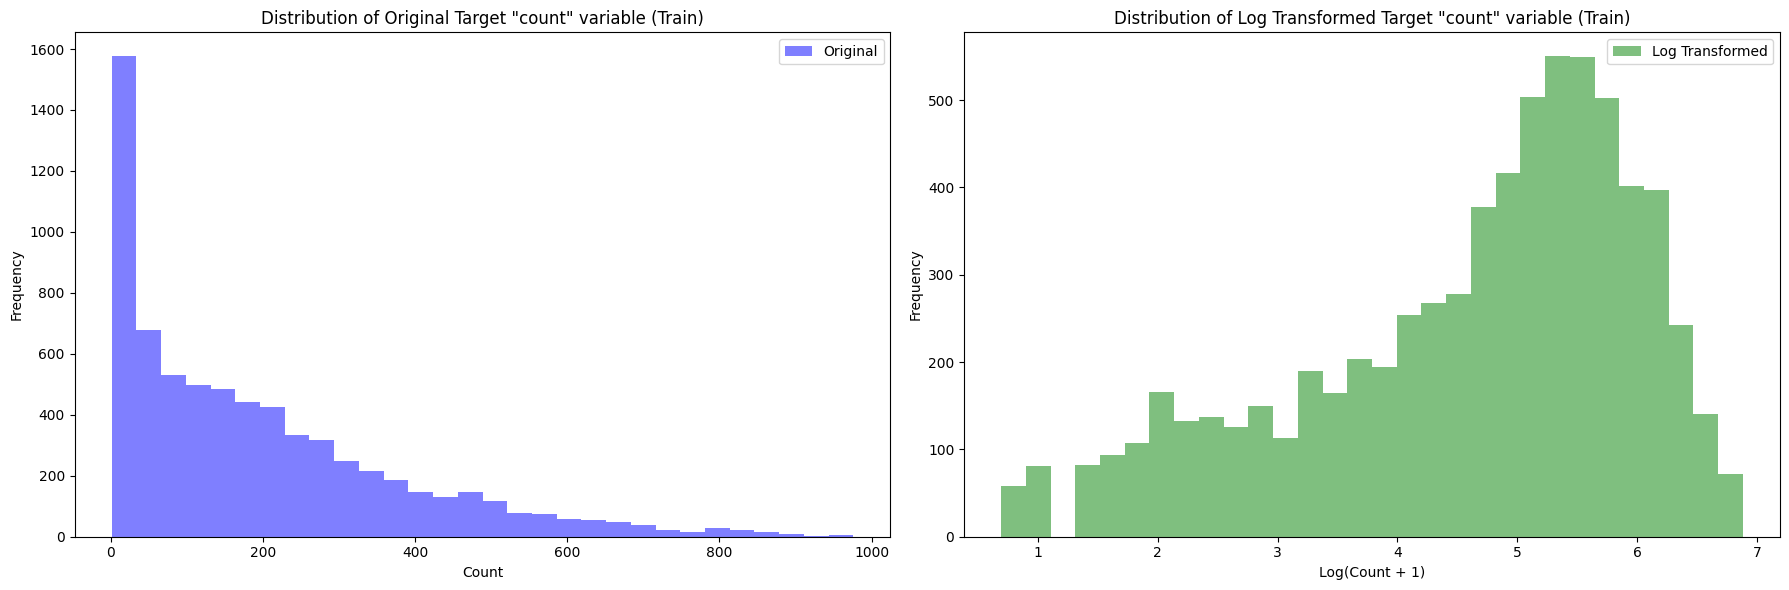

In [9]:
# Perform log transformation on 'count' variable
y_train = np.log1p(train_data['count'])
y_val = np.log1p(val_data['count'])
y_test = np.log1p(test_data['count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# Plot histogram of original 'count' variable
axes[0].hist(train_data['count'], bins=30, alpha=0.5, color='blue', label='Original')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Original Target "count" variable (Train)')
axes[0].legend()

# Plot histogram of log-transformed 'count' variable
axes[1].hist(y_train, bins=30, alpha=0.5, color='green', label='Log Transformed')
axes[1].set_xlabel('Log(Count + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Log Transformed Target "count" variable (Train)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
# Exclude 'date' from X_train
X_train_subset = X_train.drop(columns=['date'])

# Perform feature selection using SelectKBest technique that selects the top k features based on univariate statistical tests
selector = SelectKBest(score_func=f_regression, k=5)  # Select top 5 features
X_train_selected = selector.fit_transform(X_train_subset, y_train)

# Get selected feature names
selected_features = X_train_subset.columns[selector.get_support()]

# Print selected feature names
print("Selected Features:", selected_features)

# Subset all partitions using selected features
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features)
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]


Selected Features: Index(['hour', 'temp', 'atemp', 'casual', 'registered'], dtype='object')


In [11]:
# Initialize Linear Regression model
sas_lr = LinearRegression()

# Fit the model
sas_lr.fit(X_train_selected, y_train)

# Make predictions on training data
y_train_pred = sas_lr.predict(X_train_selected)

# Calculate MSE on training partition
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Training Mean Squared Error (Linear Regression): {mse_train:.3f}")

# Make predictions on validation data
y_val_pred = sas_lr.predict(X_val_selected)

# Calculate MSE on validation partition
mse_val = mean_squared_error(y_val, y_val_pred)
print(f"Validation Mean Squared Error (Linear Regression): {mse_val:.3f}")

# Make predictions on test data
y_test_pred = sas_lr.predict(X_test_selected)

# Calculate MSE on test partition
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test Mean Squared Error (Linear Regression): {mse_test:.3f}")

Training Mean Squared Error (Linear Regression): 0.502
Validation Mean Squared Error (Linear Regression): 0.525
Test Mean Squared Error (Linear Regression): 0.503
